In [1]:
# Import libraries
import os
import requests
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as ax

import pandas as pd
import rasterio
from scipy.stats import spearmanr # Using for Spearman Rank Correlation
import xarray as xr
import glob
from rasterio.mask import mask
from shapely.geometry import Point
from pyproj import Transformer
from shapely.geometry import box
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors




In [2]:
# Read in ET/GW data 1km
et_gw_merged_all_sites = "/capstone/aridgw/outputs/1km/et_precipt_ratio_1km2.csv"
et_gw_merged_all_sites = pd.read_csv(et_gw_merged_all_sites)
et_gw_merged_all_sites.head()

,year_value,site_id,depth_to_gw_ft,depth_to_gw_m,latitude,longitude,data_source,region,pct_cultivated,bbox_side,open_et_version,scaled_annual_et_avg,AI_1km2,Aridity_class,mean_et,mean_precip,et_precip_ratio
0,2000,KSGS.371852100505801,239.39,72.966072,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,781.134,0.2871,arid,797.106238,551.8382,1.444456
1,2001,KSGS.371852100505801,241.96,73.749408,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,859.635,0.2871,arid,797.106238,551.8382,1.444456
2,2002,KSGS.371852100505801,242.78,73.999344,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,787.151,0.2871,arid,797.106238,551.8382,1.444456
3,2003,KSGS.371852100505801,246.71,75.197208,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,836.748,0.2871,arid,797.106238,551.8382,1.444456
4,2004,KSGS.371852100505801,247.71,75.502008,37.31502,-100.8505,USGS,Southern Kansas,NaN,1,2.0,666.882,0.2871,arid,797.106238,551.8382,1.444456


In [3]:
site_df = et_gw_merged_all_sites.groupby('site_id').agg(
    pct_cultivated=('pct_cultivated', 'mean')
).reset_index()

site_df['pct_cultivated_class'] = site_df['pct_cultivated'].apply(
    lambda x: 'cultivated' if x >= 50 else 'non-cultivated'
)

site_df.head()


,site_id,pct_cultivated,pct_cultivated_class
0,KSGS.371852100505801,85.470085,cultivated
1,KSGS.372043101363101,49.939959,non-cultivated
2,KSGS.372539100142504,83.485202,cultivated
3,KSGS.373331098033301,79.649643,cultivated
4,KSGS.373607100565301,50.999506,cultivated


In [4]:
# Read in site summary data 1km
site_summary = "/capstone/aridgw/outputs/1km/site_summary_1km2.csv"
site_summary = pd.read_csv(site_summary)
site_summary.head()

,site_id,gw_trend_m_per_yr,region,mean_et,mean_precip,AI_1km2,Aridity_class,et_precip_ratio
0,KSGS.371852100505801,0.616701,Southern Kansas,797.106238,551.83820,0.2871,arid,1.444456
1,KSGS.372043101363101,0.213301,Southern Kansas,522.713143,514.42303,0.2302,arid,1.016115
2,KSGS.372539100142504,1.047972,Southern Kansas,829.910619,605.14417,0.3153,arid,1.371426
3,KSGS.373331098033301,0.063359,Southern Kansas,860.773810,929.18040,0.4661,arid,0.926380
4,KSGS.373607100565301,0.595615,Southern Kansas,616.277619,523.98620,0.2782,arid,1.176133


In [5]:
site_summary = site_df.merge(site_summary, on='site_id', how='outer')
site_summary

,site_id,pct_cultivated,pct_cultivated_class,gw_trend_m_per_yr,region,mean_et,mean_precip,AI_1km2,Aridity_class,et_precip_ratio
0,KSGS.371852100505801,85.470085,cultivated,0.616701,Southern Kansas,797.106238,551.83820,0.2871,arid,1.444456
1,KSGS.372043101363101,49.939959,non-cultivated,0.213301,Southern Kansas,522.713143,514.42303,0.2302,arid,1.016115
2,KSGS.372539100142504,83.485202,cultivated,1.047972,Southern Kansas,829.910619,605.14417,0.3153,arid,1.371426
3,KSGS.373331098033301,79.649643,cultivated,0.063359,Southern Kansas,860.773810,929.18040,0.4661,arid,0.926380
4,KSGS.373607100565301,50.999506,cultivated,0.595615,Southern Kansas,616.277619,523.98620,0.2782,arid,1.176133
5,KSGS.374111099070401,61.503143,cultivated,0.176172,Southern Kansas,800.964048,737.78490,0.3797,arid,1.085634
6,KSGS.374125100344101,76.824186,cultivated,1.690761,Southern Kansas,795.150381,576.21246,0.3101,arid,1.379960
7,KSGS.374747100552101,88.479198,cultivated,1.912739,Southern Kansas,885.796714,526.87335,0.2908,arid,1.681233
8,KSGS.375145100485701,73.504274,cultivated,1.217462,Southern Kansas,899.119333,531.41736,0.2917,arid,1.691927
9,KSGS.375454101075401,84.325775,cultivated,1.541198,Southern Kansas,999.956667,532.69920,0.2784,arid,1.877151


# RAW PLOT

/tmp/ipykernel_1993138/1041355462.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Set1', len(regions))


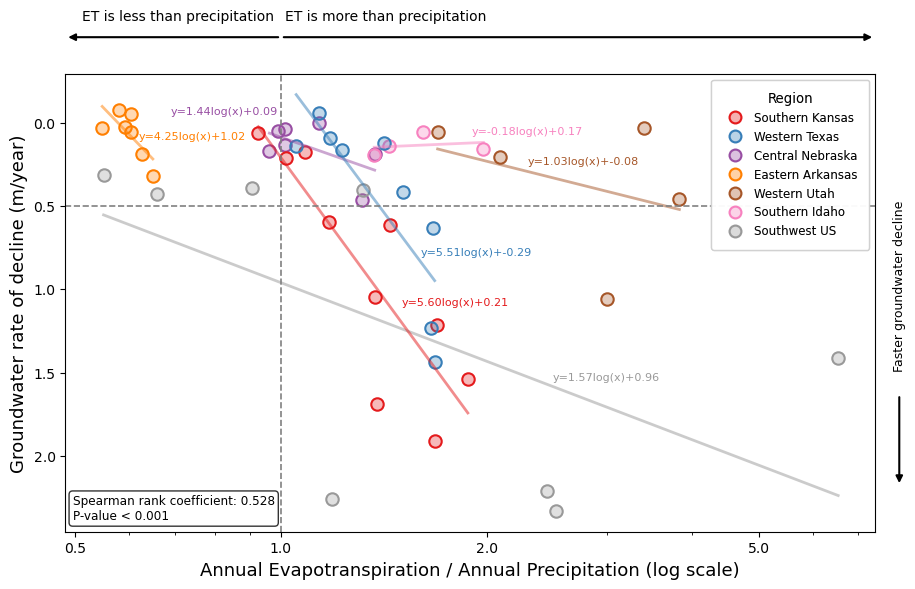

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# --- assign consistent colors to regions ---
regions = site_summary["region"].unique()
colors = cm.get_cmap('Set1', len(regions))
color_map = {r: colors(i) for i, r in enumerate(regions)}

# --- marker map for cultivated class ---
marker_map = {
    'cultivated': '*',
    'non-cultivated': 'o'
}

label_positions = { "Southern Kansas": (1.5, 1.1), 
                   "Western Texas": (1.6, 0.8), 
                   "Central Nebraska": (0.69, -0.05), 
                   "Arkansas Delta": (.62, 0.1), 
                   "Western Utah": (2.3, 0.25), 
                   "Southern Idaho": (1.9, 0.07), 
                   "SoCal_Arizona": (2.5, 1.55) 
}


# --- plot ---
for region, group in site_summary.groupby("region"):
    
    base_color = color_map[region]
    face_color = mcolors.to_rgba(base_color, alpha=0.3)
    
    ax.scatter(
        group["et_precip_ratio"],
        group["gw_trend_m_per_yr"],
        s=80,
        marker='o',                    # single shape
        facecolors=face_color,
        edgecolors=base_color,
        linewidths=1.5
    )    
    x = group["et_precip_ratio"].values
    y = group["gw_trend_m_per_yr"].values
    
    # log transform for regression
    log_x = np.log10(x)
    
    # remove bad values
    mask = np.isfinite(log_x) & np.isfinite(y)
    log_x = log_x[mask]
    y = y[mask]
    x = x[mask]
    
    if len(log_x) > 1:
        # fit regression
        slope, intercept = np.polyfit(log_x, y, 1)
        
        # line only over this region's range
        x_line = np.linspace(min(x), max(x), 100)
        y_line = slope * np.log10(x_line) + intercept
        
        # plot line
        ax.plot(x_line, y_line, color=base_color, linewidth=2, alpha=0.5)
        
        # add equation label
        default_pos = (np.median(x), slope * np.log10(np.median(x)) + intercept)
        pos = label_positions.get(region, default_pos)
        ax.text(pos[0], pos[1], f"y={slope:.2f}log(x)+{intercept:.2f}",
                color=base_color, fontsize=8)

# --- labels ---
ax.set_xlabel("Annual Evapotranspiration / Annual Precipitation (log scale)", fontsize=13)
ax.set_ylabel("Groundwater rate of decline (m/year)", fontsize=13)
ax.invert_yaxis()

# --- down arrow on RIGHT side ---
ax.annotate(
    "",
    xy=(1.03, 0.1),
    xytext=(1.03, 0.3),
    xycoords="axes fraction",
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5)
)
ax.text(
    1.03, 0.35,
    "Faster groundwater decline",
    transform=ax.transAxes,
    ha="center", va="bottom",
    fontsize=9, color="black",
    rotation=90
)

# --- fast decline line ---
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.2)

# dashed line at x axis
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.2)

# --- arrows at top showing ET vs precipitation ---

# RIGHT arrow
ax.annotate(
    "",
    xy=(1, 1.08),
    xytext=(1, 1.08),
    xycoords=("axes fraction", "axes fraction"),
    textcoords=("data", "axes fraction"),
    arrowprops=dict(arrowstyle="-|>", lw=1.5, color="black")
)
ax.text(0.52, 1.11, "ET is more than precipitation",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10)

# LEFT arrow
ax.annotate(
    "",
    xy=(0.00, 1.08),
    xytext=(1, 1.08),
    xycoords=("axes fraction", "axes fraction"),
    textcoords=("data", "axes fraction"),
    arrowprops=dict(arrowstyle="-|>", lw=1.5, color="black")
)
ax.text(0.02, 1.11, "ET is less than precipitation",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10)


# Fix legend region name (SoCal_Arizona)
region_legend = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markersize=8.5,
        markerfacecolor=mcolors.to_rgba(color_map[r], alpha=0.3),  # light fill
        markeredgecolor=color_map[r],                              # dark outline
        markeredgewidth=1.5,
        label=r.replace("SoCal_Arizona", "Southwest US")
               .replace("Arkansas Delta", "Eastern Arkansas")
               .replace("_", " ")
    )
    for r in regions
]

legend1 = ax.legend(handles=region_legend, 
                    title="Region", 
                    loc="upper right",
                    fontsize=8.5,
                    title_fontsize=9.5,
                    borderpad=1,
                    labelspacing=0.5,
                    handletextpad=0.6)

ax.add_artist(legend1)

# put x on log scale
ax.set_xscale('log')

# fix axis tics
ax.set_xticks([0.5, 1, 2, 5])
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

# Spearman rank text box
ax.text(0.009, 0.02, "Spearman rank coefficient: 0.528\nP-value < 0.001",
        transform=ax.transAxes, fontsize=8.7,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(right=0.88)  # make room for right side arrow
plt.show()